# Misure di Performance di un Algoritmo di Classificazione


Le **misure di performance** (o metriche) sono strumenti essenziali per valutare quanto bene un algoritmo di classificazione svolge il suo compito.

Nella scorsa lezione abbiamo visto un esempio di algoritmo di classificazione supervisionato: il decision tree.
Come faccio, però, a vedere se l'algoritmo funziona?

Soprattutto come capisco  se funziona su nuovi dati "non visti" dall'algoritmo?

Vedremo le principali metriche per stimare le performance di un algoritmo di classificazione.

Ricordiamo che la classificazione può essere binaria o multiclasse.

Binaria se la variabile target assume solo due valori (per esempio 0 o 1).
Multiclasse se abbiamo più label da classificare.

Dovremo analizzare, quindi, entrambe le possibilità.

L'approccio più semplice, un primo step "intuitivo", è quello di dividere il dataset di cui si conosce già la risposta in due gruppi:
- Dataset di training
- Dataset di test

Le misure di performance che si costruiranno vanno valutate sia sul dataset di training che su quello di test.

Ovviamente ci si aspetta che l'algoritmo funzioni almeno sul dataset su cui sono stati allenati gli algoritmi.

Sono possibili approcci diversi (divisione in dataset di training, test e validation e, vedremo, la cross validation)

### Importante osservazione:

In generale le performance di un algoritmo non sono mai perfette (e se lo sono è meglio dubitare). E' sempre trovare un "equilibrio" fra i risultati ottenibili e le esigenze del problema confrontansosi con "il cliente" o comunque con le persone che hanno richiesto la realizzazione dell'algoritmo.

Idealmente quale metrica massimizzare è frutto di riflessioni e confronto persone che potrebbero non avere competenze tecniche.

E' importante quindi spiegare correttamente i limiti e il significato di quanto viene presentato.

# La Matrice di confusione

Nell'apprendimento automatico, una matrice di confusione, nota anche come matrice di errore, è una specifica disposizione di tabella che consente la visualizzazione delle prestazioni di un algoritmo, in genere di apprendimento supervisionato.

Ogni riga della matrice rappresenta le istanze di una classe effettiva, mentre ogni colonna rappresenta le istanze di una classe prevista, o viceversa: entrambe le varianti sono presenti in letteratura.

La **Confusion Matrix** (o matrice di confusione) è, in altri termini, una tabella che riassume tutte le predizioni del modello confrontandole con i valori reali.

La diagonale della matrice rappresenta quindi tutte le istanze previste correttamente.

Il nome deriva dal fatto che semplifica l'identificazione di eventuali confuse tra classi da parte del sistema (ovvero, spesso etichettando erroneamente una classe come un'altra).

La matrice di confusione ha origine negli studi sulla percezione umana degli stimoli uditivi. È stata adattata per gli studi di apprendimento automatico e utilizzata da Frank Rosenblatt, tra gli altri primi ricercatori, per confrontare le classificazioni umane e automatiche degli stimoli visivi (e successivamente uditivi).

Un modello potrebbe avere un'**accuratezza alta** ma comportarsi male su una classe specifica. Senza metriche dettagliate, non lo accorgeresti.

### Classificazione Binaria vs Multi-classe

In questa lezione ci concentriamo prevalentemente sulla **classificazione binaria** (due classi), dove le classi vengono tipicamente etichettate:
- **Classe Positiva (1):** il caso di interesse (es. malattia, frode, spam)
- **Classe Negativa (0):** il caso "normale" (es. sano, transazione legittima, email legittima)


Nel caso di classificazione con un numero di classi superiore a due (multiclasse) il ragionamento è analogo ma la matrice di confusione terrà conto della frequenza di tutti i possibili errori di classificazione (per esempio: l'algoritmo prevede classe "2" e invece è classe "3").



### Schema matrice di confusione nel caso della **Classificazione Binaria**

```
                    ┌─────────────────────────────┐
                    │       PREDETTO DAL MODELLO   │
                    │                             │
                    │    Negativo      Positivo   │
         ┌──────────┼────────────┬────────────────┤
         │ Negativo │     TN     │      FP        │
  REALE  │          │            │                │
         ├──────────┼────────────┼────────────────┤
         │ Positivo │     FN     │      TP        │
         │          │            │                │
         └──────────┴────────────┴────────────────┘
```

### Definizioni utili:

| Acronimo | Nome | Significato |
|----------|------|-------------|
| **TP** | True Positive | Il modello ha predetto Positivo ed è davvero Positivo  |
| **TN** | True Negative | Il modello ha predetto Negativo ed è davvero Negativo  |
| **FP** | False Positive | Il modello ha predetto Positivo ma è Negativo  |
| **FN** | False Negative | Il modello ha predetto Negativo ma è Positivo  |

### Esempio Clinico

**Scenario:** Modello per la diagnosi di un tumore.
- Classe Positiva = Paziente con tumore
- Classe Negativa = Paziente sano

```
Risultati su 1010 pazienti:

                    PREDETTO
                 Negativo  Positivo
REALE Negativo     890        50       → 940 sani
      Positivo      30        40       → 70 malati
                   ─────     ─────
                   920        90       → 1010 totali
```

**Interpretazione:**
- **TP = 40:** 40 pazienti malati correttamente identificati
- **TN = 890:** 890 pazienti sani correttamente identificati
- **FP = 50:** 50 pazienti sani erroneamente diagnosticati come malati (falsi allarmi)
- **FN = 30:** 30 pazienti malati NON identificati → **Problema da analizzare con i medici**

---

## Analisi delle  Metriche Base
Qui di seguito analizziamo le metriche di base che vengono calcolate a partire dalla matrice di confusione.

Per ognuna vedremo la formula teorica e la sua applicazione nell'esempio precedente.


###  Accuracy (Accuratezza)

**Formula:**
```
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

**Nell'esempio:**
```
Accuracy = (40 + 890) / 1010 = 930/1010 = 0.92 (92%)
```

**Interpretazione:** Il modello classifica correttamente il 92% dei casi.

**ATTENZIONE - Limite principale:**

L'Accuracy può essere **ingannevole con dataset sbilanciati**!

Per dataset sbilanciato intendiamo dataset in cui un evento (in genere quello che si vuole predire) è molto più frequente dell'altro (o degli altri).


```
Esempio patologico:
- 950 pazienti sani, 70 malati
- Un modello che predice SEMPRE "sano" ha:
  Accuracy = 950/1010 = 94% ... ma Recall = 0%!
  (non trova NESSUN paziente malato)
```

**Quando usare solo accuracy:** Solo quando le classi sono **bilanciate** (o vicine ad essere bilanciate).

---

###  Recall (Sensibilità / Sensitivity / True Positive Rate)

**Formula:**
```
Recall = TP / (TP + FN)
```

**Nell'esempio:**
```
Recall = 40 / (40 + 30) = 40/70 = 0.571 (57.1%)
```

**Interpretazione:** Di tutti i pazienti malati, il modello ne ha trovati solo il 57.1%.

**Domanda che risponde:** *"Di tutti i casi positivi reali, quanti ne ho trovati?"*

**Quando è CRITICA:** Quando i False Negative sono pericolosi:
- Diagnosi medica (paziente malato non identificato)
- Screening oncologico
- Rilevamento frodi finanziarie


---

###  Precision (Precisione / Positive Predictive Value)

**Formula:**
```
Precision = TP / (TP + FP)
```

**Nell'esempio:**
```
Precision = 40 / (40 + 50) = 40/90 = 0.444 (44.4%)
```

**Interpretazione:** Dei pazienti che il modello classifica come "malati", solo il 44.4% lo è davvero.

**Domanda che risponde:** *"Di tutti i casi che ho predetto come positivi, quanti sono davvero positivi?"*

** Quando è CRITICA:** Quando i False Positive sono costosi:
- Interventi chirurgici non necessari
- Blocco di transazioni legittime
- Messaggi di allarme errati

---

### Specificity (Specificità / True Negative Rate)

**Formula:**
```
Specificity = TN / (TN + FP)
```

**Nell'esempio:**
```
Specificity = 890 / (890 + 50) = 890/940 = 0.947 (94.7%)
```

**Interpretazione:** Di tutti i pazienti sani, il modello ne ha correttamente identificati il 94.7%.

**Domanda che risponde:** *"Di tutti i casi negativi reali, quanti ne ho correttamente identificati?"*

---

###  Relazioni tra le Metriche

```
┌─────────────────────────────────────────────────┐
│                                                 │
│  Recall = TP / (TP + FN)     → guarda la RIGA   │
│  (sensibilità sulla classe positiva)            │
│                                                 │
│  Precision = TP / (TP + FP)  → guarda la COLONNA│
│  (precisione sulla classe positiva)             │
│                                                 │
│  Specificity = TN / (TN + FP) → guarda la RIGA  │
│  (sensibilità sulla classe negativa)            │
│                                                 │
│  NPV = TN / (TN + FN)        → guarda la COLONNA│
│  (precisione sulla classe negativa)             │
│                                                 │
└─────────────────────────────────────────────────┘
```

**NPV (Negative Predictive Value):**
```
NPV = TN / (TN + FN) = 890 / (890 + 30) = 0.967 (96.7%)
```

---

##  Ulteriori metriche da considerare

###  F1-Score

Il **F1-Score** è la media armonica di Precision e Recall. Bilancia entrambe le metriche in un unico valore.

**Formula:**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

**Nell'esempio:**
```
F1 = 2 × (0.444 × 0.571) / (0.444 + 0.571)
F1 = 2 × 0.2535 / 1.015
F1 = 0.507 / 1.015
F1 = 0.4995 ≈ 0.50
```

** Perché media armonica e non media aritmetica?**

Inseriamo una breve spiegazione sulla differenza fra media aritmetica e media armonica (per tua curiosità vedi anche definizione media geometrica).


### Media Aritmetica (La media "classica")
È la somma di tutti i valori divisa per il numero dei dati.

* **Formula:** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$
* **Utilizzo principale:** Dati additivi (altezze, temperature, voti d'esame).
* **Punto debole:** È molto sensibile ai **valori estremi alti** (outliers). Un solo valore molto grande sposta la media verso l'alto, anche se non rappresenta la maggioranza del gruppo.

### Media Armonica (La media dei "tassi")

È il reciproco della media aritmetica dei reciproci.

* **Formula:**: $H = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}$
* **Utilizzo principale:** Rapporti, velocità, produttività o quando si ha il tempo al denominatore.
* **Punto di forza:** È sensibile ai **valori estremi bassi**. Tende a "punire" il risultato se anche solo un valore è molto vicino allo zero.

---


 L'**F1-Score** è la media armonica tra *Precision* e *Recall*. Si usa l'armonica perché se il tuo modello ha una Precision ottima (100%) ma una Recall pessima (0%), la media aritmetica ti darebbe il 50% (falsa sicurezza), mentre la media armonica ti darebbe **0%**, segnalando correttamente che il modello è inutile.


---


La media armonica, quindi, penalizza maggiormente i valori bassi:
```
Esempio:
  Precision = 0.90, Recall = 0.10

  Media aritmetica: (0.90 + 0.10) / 2 = 0.50 (sembra ok)
  Media armonica:   2×0.90×0.10 / (0.90+0.10) = 0.18 (rivela il problema!)
```

---

###  (CENNI) F-Beta Score (Generalizzazione di F1)

Il **F-beta** permette di dare più peso a Precision o Recall.

**Formula:**
```
Fβ = (1 + β²) × (Precision × Recall) / (β² × Precision + Recall)
```

| β | Priorità | Quando usare |
|---|----------|--------------|
| β < 1 | **Precision** conta di più | Quando i falsi positivi sono costosi |
| β = 1 | Bilancio pareggiato | F1-Score standard |
| β > 1 | **Recall** conta di più | Quando i falsi negativi sono pericolosi |
| β = 2 | Recall conta il doppio | Diagnosi medica, screening |

**Esempio con β = 2 (F2-Score):**
```
F2 = (1 + 4) × (0.444 × 0.571) / (4 × 0.444 + 0.571)
F2 = 5 × 0.2535 / (1.776 + 0.571)
F2 = 1.2675 / 2.347
F2 = 0.540
```

---

### (CENNI)  Cohen's Kappa

Misura l'accordo tra le predizioni del modello e i valori reali, **correggendo per il caso**.


Il **coefficiente Kappa di Cohen** ($\kappa$) è una misura statistica che quantifica il grado di concordanza tra due classificatori (o tra un modello e la realtà), tenendo conto della concordanza che potrebbe verificarsi **per puro caso**.

A differenza della semplice accuratezza, il Kappa corregge l’accordo osservato sottraendo la componente attesa casualmente.

Fu introdotto dallo statistico **Jacob Cohen** nel 1960.

---

## Formula del Kappa

Il coefficiente è definito come:


$\kappa = \frac{P_o - P_e}{1 - P_e}$


Dove:

* $P_o$ = **accordo osservato**
* $P_e$ = **accordo atteso per caso**

---

## Calcolo tramite Matrice di Confusione (caso binario)

Consideriamo una matrice di confusione:

|            | Reale 1 | Reale 0 | Totale |
| ---------- | ------- | ------- | ------ |
| Predetto 1 | TP      | FP      | $P_1$  |
| Predetto 0 | FN      | TN      | $P_0$  |
| Totale     | $R_1$   | $R_0$   | $N$    |

### Accordo osservato

È la proporzione di osservazioni correttamente classificate:

$
P_o = \frac{TP + TN}{N}
$

---

###  Accordo atteso per caso

Si calcola utilizzando le probabilità marginali.

Probabilità che entrambi predicano 1 per caso:

$
\frac{P_1}{N} \cdot \frac{R_1}{N}
$

Probabilità che entrambi predicano 0 per caso:

$
\frac{P_0}{N} \cdot \frac{R_0}{N}
$

Sommandole otteniamo:

$
P_e = \frac{P_1 R_1 + P_0 R_0}{N^2}
$

---

## Interpretazione del Kappa

Il coefficiente assume valori nel range:

$
-1 \leq \kappa \leq 1
$

* $\kappa = 1$ → concordanza perfetta
* $\kappa = 0$ → accordo pari al caso
* $\kappa < 0$ → accordo peggiore del caso

### Scala di Landis & Koch

| Valore Kappa | Interpretazione |
| ------------ | --------------- |
| < 0          | Poor            |
| 0.00–0.20    | Slight          |
| 0.21–0.40    | Fair            |
| 0.41–0.60    | Moderate        |
| 0.61–0.80    | Substantial     |
| 0.81–1.00    | Almost perfect  |

---

Nei dataset molto sbilanciati la classe positiva è spesso rara.

Un modello può ottenere un'accuratezza elevata semplicemente predicendo sempre la classe maggioritaria. Tuttavia:

* L’**accuracy** non penalizza questo comportamento.
* Il **Kappa** invece riduce il punteggio se l’accordo è dovuto principalmente allo sbilanciamento delle classi.

Ad esempio, un valore di:

$
\kappa = 0.21
$

indica una concordanza **“fair”**, quindi solo leggermente migliore del caso — segnale che il modello fatica a distinguere la classe positiva dal rumore.

---

## Relazione con Accuracy

Possiamo riscrivere il Kappa come:

$
\kappa = \frac{\text{Accuracy} - P_e}{1 - P_e}
$

Quindi:

* Se $P_e$ è alto (dataset molto sbilanciato), anche una buona accuracy può produrre un Kappa basso.
* Il Kappa misura il **valore informativo reale del modello**.


In sintesi: **Formula:**
```
κ = (Po - Pe) / (1 - Pe)

Dove:
  Po = Accuracy osservata = (TP + TN) / N
  Pe = Accuracy attesa per caso
     = [(TP+FP)(TP+FN) + (TN+FN)(TN+FP)] / N²
```

**Nell'esempio:**
```
Po = 930/1010 = 0.92

Pe = [(90×70) + (910×930)] / 1000²
Pe = [6300 + 846300] / 1000000
Pe = 852600 / 1000000
Pe = 0.8526

κ = (0.92 - 0.8526) / (1 - 0.8526)
κ = 0.0774 / 0.1474
κ = 0.525
```

**Scala di interpretazione:**

| κ | Interpretazione |
|---|-----------------|
| < 0 | Nessun accordo |
| 0.01 - 0.20 | Accordo minimo |
| 0.21 - 0.40 | Accordo discreto |
| 0.41 - 0.60 | Accordo moderato |
| 0.61 - 0.80 | Accordo sostanziale |
| 0.81 - 1.00 | Accordo quasi perfetto |

Nel nostro caso: κ = 0.525 → **Accordo moderato**

---

### Matthews Correlation Coefficient (MCC)

Considerata una delle metriche più affidabili per classificazione binaria, specialmente con classi sbilanciati.

**Formula:**
```
MCC = (TP×TN - FP×FN) / √[(TP+FP)(TP+FN)(TN+FP)(TN+FN)]
```

**Nell'esempio:**
```
Numeratore = TP×TN - FP×FN = 40×890 - 50×30 = 35600 - 1500 = 34100

Denominatore = √[(40+50)(40+30)(890+50)(890+30)]
             = √[90 × 70 × 940 × 920]
             = √[5,466,048,000]
             = 73,932.7

MCC = 34100 / 73932.7 = 0.461
```

**Scala:**

| MCC | Interpretazione |
|-----|-----------------|
| -1 | Predizione totalmente sbagliata |
| 0 | Equivalente a predizione casuale |
| +1 | Predizione perfetta |

Nel nostro caso: MCC = 0.461 → **Performance moderata**

---

##  Curve ROC e Precision-Recal


La curva ROC rappresenta la relazione tra **True Positive Rate (Recall)** e **False Positive Rate (FPR)** per diverse soglie di decisione.

**Assi:**
- **Asse X:** FPR = FP / (FP + TN) = 1 - Specificity
- **Asse Y:** TPR = TP / (TP + FN) = Recall

**Come si costruisce:**

```
1. Il modello assegna una probabilità p a ogni campione
2. Si variano le soglie da 1 a 0
3. Per ogni soglia si calcolano TPR e FPR
4. Si plottano i punti (FPR, TPR)

Soglia alta (es. 0.9):
  → Pochi positivi predetti → Recall basso, FPR basso

Soglia bassa (es. 0.1):
  → Molti positivi predetti → Recall alto, FPR alto
```

**Interpretazione:**

```
         TPR (Recall)
          1 ┤         ╭──────────●
            │       ╭─╯  BUON
            │     ╭─╯   MODELLO
            │   ╭─╯
            │  ╱  AUC = Area sotto la curva
            │ ╱
            │╱  Modello Casuale
          0 ┼─────────────────────
            0                     1
                  FPR (1 - Specificity)
```

###  AUC (Area Under the Curve)

L'**AUC** è l'area sotto la curva ROC. Rappresenta la probabilità che il modello assegni una probabilità più alta a un campione positivo casuale rispetto a uno negativo casuale.

**Scala AUC:**

| AUC | Qualità del Modello |
|-----|---------------------|
| 0.50 | Equivalente a casuale (moneta) |
| 0.60 - 0.70 | Scarsa |
| 0.70 - 0.80 | Discreta |
| 0.80 - 0.90 | Buona |
| 0.90 - 1.00 | Eccellente |
| 1.00 | Perfetto |

**Vantaggio dell'AUC:** Non dipende da una singola soglia di decisione.

---

###  Curva Precision-Recall

Rappresenta il trade-off tra Precision e Recall per diverse soglie.

**Quando preferire alla ROC:**
- Dataset molto sbilanciati
- Quando la classe positiva è rara
- Quando entrambe Precision e Recall sono importanti

**Interpretazione:**
```
  Precision
      1 ┤ ●
        │  ╲
        │   ╲     BUON MODELLO
        │    ╲   ╭──●
        │     ╲ ╱
        │      ╳
        │     ╱ ╲
        │   ╱    ╲  MODELLO CASUALE
      0 ┼─────────────────
        0                 1
              Recall
```

---



In [1]:
# 1. Dati di esempio
y_vere = [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]

def crea_matrice(vere, pred):
    # Inizializziamo una matrice 2x2 piena di zeri
    # Struttura: [[TN, FP], [FN, TP]]
    matrice = [[0, 0],
               [0, 0]]

    # Popoliamo la matrice usando i valori come indici
    for v, p in zip(vere, pred):
        matrice[v][p] += 1

    return matrice

# 2. Calcolo
risultato = crea_matrice(y_vere, y_pred)

# 3. Stampa formattata
print("Matrice di Confusione:")
for riga in risultato:
    print(riga)

# Spiegazione degli indici
print(f"\nLegenda:")
print(f"TN: {risultato[0][0]} | FP: {risultato[0][1]}")
print(f"FN: {risultato[1][0]} | TP: {risultato[1][1]}")

Matrice di Confusione:
[4, 1]
[2, 3]

Legenda:
TN: 4 | FP: 1
FN: 2 | TP: 3


Matrice di Confusione (array):
[[4 1]
 [2 3]]


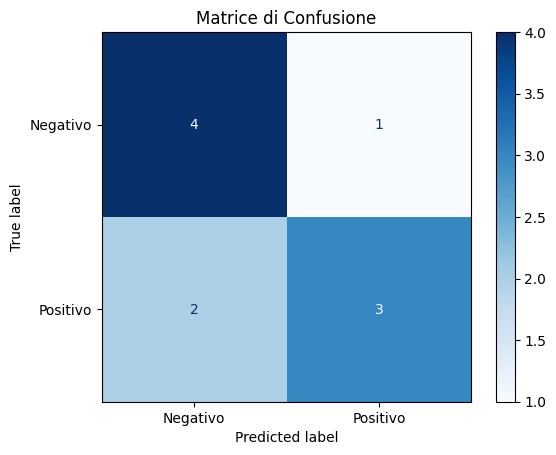

In [2]:
# Confusion matrix con uso librerie

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. I tuoi dati (0 = Negativo, 1 = Positivo)
y_vere = [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]

# 2. Calcolo della matrice di confusione
# Restituisce un array: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_vere, y_pred)

print("Matrice di Confusione (array):")
print(cm)

# 3. Visualizzazione grafica
# labels=[0, 1] specifica l'ordine delle classi
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])

disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice di Confusione")
plt.show()

0.9
0.85
0.8
0.7
0.6
0.5
0.4
0.3
0.2
0.1


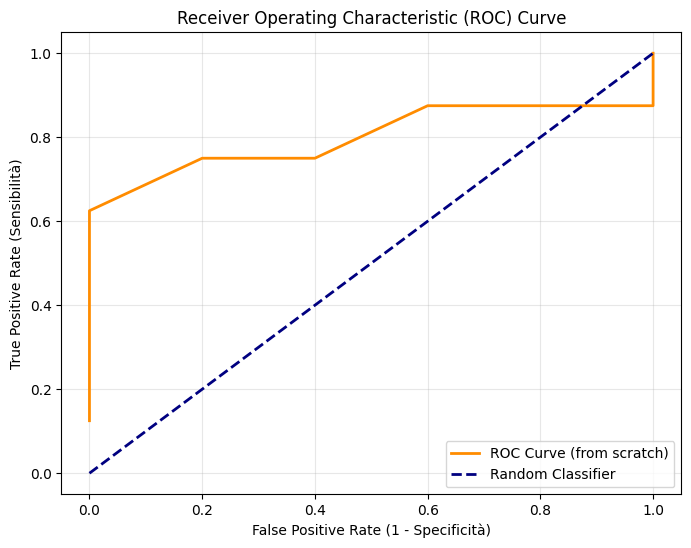

In [3]:
# Di questo codice fatti solo cenni a lezione
# esempio di codice per costruire la curva della ROC da "zero"

import numpy as np
import matplotlib.pyplot as plt


def calcola_roc_scratch(y_real, y_proba):
    # Ordiniamo le probabilità in modo decrescente
    # Le soglie saranno i valori unici di probabilità
    thresholds = np.unique(y_proba)
    thresholds = np.sort(thresholds)[::-1]

    tpr_list = []
    fpr_list = []

    # Calcolo totali positivi e negativi reali
    P = np.sum(y_real == 1)
    N = np.sum(y_real == 0)

    for t in thresholds:
        print(t)

        # Applichiamo la soglia: 1 se proba >= t, altrimenti 0
        y_pred = (y_proba >= t).astype(int)

        # Calcolo True Positives e False Positives
        tp = np.sum((y_pred == 1) & (y_real == 1))
        fp = np.sum((y_pred == 1) & (y_real == 0))

        # True Positive Rate = TP / P
        # False Positive Rate = FP / N
        tpr_list.append(tp / P)
        fpr_list.append(fp / N)

    return fpr_list, tpr_list

# --- Simulazione Dati ---
np.random.seed(42)
y_real = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0,1,1,1])
y_proba = np.array([0.9, 0.4, 0.8, 0.7, 0.2, 0.6, 0.1, 0.5, 0.85, 0.3,0.6,0.7,0.4])

# Calcolo
fpr, tpr = calcola_roc_scratch(y_real, y_proba)

# --- Grafico ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (from scratch)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [4]:
# solo cenni
# rivedi codice per calcolare area approssimata con metodo dei rettangoli o dei
#trapezi


def calcola_auc(y_vere, y_prob):
    # 1. Creiamo coppie (probabilità, valore_vero) e ordiniamo per probabilità decrescente
    dati = sorted(zip(y_prob, y_vere), reverse=True)

    tp = 0
    fp = 0
    punti = []

    tot_positivi = sum(y_vere)
    tot_negativi = len(y_vere) - tot_positivi

    # 2. Calcoliamo TPR e FPR per ogni possibile soglia data dai dati
    punti.append((0, 0)) # Punto di partenza (soglia > 1)
    for _, reale in dati:
        if reale == 1:
            tp += 1
        else:
            fp += 1
        punti.append((fp / tot_negativi, tp / tot_positivi))

    # 3. Integrazione numerica (Regola del Trapezio)
    auc = 0.0
    for i in range(1, len(punti)):
        # Area trapezio = (base_maggiore + base_minore) * altezza / 2
        # Qui: altezza = delta FPR, basi = valori di TPR
        x0, y0 = punti[i-1]
        x1, y1 = punti[i]
        auc += (x1 - x0) * (y1 + y0) / 2

    return auc

# Test
y_prob = [0.1, 0.85, 0.2, 0.45, 0.05, 0.9, 0.7, 0.6, 0.3, 0.2]
y_vere = [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]

print(f"L'Area Sotto la Curva (AUC) è: {calcola_auc(y_vere, y_prob):.4f}")

L'Area Sotto la Curva (AUC) è: 0.9200


##  Metriche per Classificazione Multi-classe

###  Strategie di Aggregazione

Con più di 2 classi, le metriche come Precision, Recall e F1 devono essere aggregate. Ci sono tre metodi principali:

**Macro Average:**
```
Calcola la metrica per ogni classe e ne fa la MEDIA SEMPLICE.
Ogni classe ha lo stesso peso.

Macro-Precision = (Precision_classe1 + Precision_classe2 + ... ) / n_classi
```

**Weighted Average:**
```
Calcola la metrica per ogni classe e la PESA per il numero di campioni.
Le classi più frequenti hanno più peso.

Weighted-Precision = Σ (support_i × Precision_i) / N_totale
```

**Micro Average:**
```
Calcola TP, FP, FN TOTALI e poi applica la formula.
Equivale all'Accuracy in classificazione multi-classe.

Micro-Precision = TP_totale / (TP_totale + FP_totale)
```

### Quando Usare Quale

| Strategia | Quando Usare |
|-----------|--------------|
| **Macro** | Tutte le classi sono ugualmente importanti |
| **Weighted** | Le classi hanno frequenze diverse ma tutte importanti |
| **Micro** | Vuoi la performance globale complessiva |

---

##  Scelta della Metrica "Giusta"
Qui di seguito inseriamo una schema decisionale per individuare la metrica più opportuna da utilizzare.


```
┌─────────────────────────────────────────────────────────┐
│              COME SCEGLIERE LA METRICA?                  │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  Dataset BILANCIATO?                                    │
│  ├── SÌ → Accuracy + F1 sono buone scelte              │
│  └── NO → Evita Accuracy, usa F1, AUC, MCC             │
│                                                         │
│  Cosa conta di più?                                     │
│  ├── Trovare tutti i positivi → RECALL                  │
│  │   (diagnosi medica, screening)                       │
│  ├── Essere precisi sui positivi → PRECISION            │
│  │   (spam filter, interventi chirurgici)               │
│  ├── Bilancio tra i due → F1-Score                      │
│  └── Nessuna preferenza speciale → AUC-ROC              │
│                                                         │
│  Dati clinici?                                          │
│  └── Usa sempre Recall + Specificity + AUC              │
│                                                         │
│  Classi molto sbilanciati?                              │
│  └── MCC + Precision-Recall Curve                       │
│                                                         │
└─────────────────────────────────────────────────────────┘
```

###  Esempi Pratici

Vediamo alcuni esempi pratici per ragionare su quali metriche potrebbe essere più opportuno utilizzare.


| Applicazione | Metrica Principale | Perché |
|--------------|-------------------|--------|
| Diagnosi tumore | **Recall** | Non vogliamo perdere malati |
| Filtro spam | **Precision** | Non vogliamo bloccare email legittime |
| Rilevamento frodi | **F1** | Bilanciare falsi allarmi e frodi mancate |
| Sistema di raccomandazione | **Precision@K** | Le prime K raccomandazioni devono essere buone |
| Guida autonoma | **Recall** | Ogni errore potrebbe essere fatale |

---


# Approfondimento: la  **Cross-Validation**

Abbiamo visto che per vedere se il nostro algoritmo di Machine Learning sta funzionando o meno buona norma testare l'algoritmo su un dataset di test diverso da quello di training su cui l'algoritmo è stato allenato.

Esistono, in realtà, delle tecniche migliore di separare in due il dataset.
Una delle più utilizzate (possiamo dire lo stato dell'arte nel ML) è la validazione incrociata.

La **Cross-Validation** (validazione incrociata) è una tecnica statistica fondamentale nel Machine Learning utilizzata per valutare la capacità di generalizzazione di un modello. In parole semplici, serve a capire come il tuo modello si comporterà su dati nuovi che non ha mai visto durante l'addestramento.

Quando addestriamo un modello, il rischio principale è l'**overfitting**: il modello impara "a memoria" i dati di training (inclusi i rumori e gli errori casuali), ma fallisce  quando deve fare previsioni su nuovi pazienti o situazioni.

Se dividiamo i dati solo in un semplice blocco "Train" e un blocco "Test", il risultato potrebbe dipendere dalla fortuna (o sfortuna) di come sono stati divisi i dati.

Intuitivamente, possiamo affermare che realizzare  la Cross-Validation è come sottoporre il tuo modello a diversi esami invece di uno solo. Se il modello passa tutti gli esami con voti simili, puoi essere fiducioso che funzionerà bene anche nel mondo reale.


### Concetto centrare della  Cross-Validation (K-Fold)

La tecnica più comune è la **K-Fold Cross-Validation**. Il procedimento segue questi passaggi:

1. Si divide l'intero dataset in **K parti** uguali (chiamate "fold").
2. Il processo di addestramento viene ripetuto **K volte**.
3. In ogni iterazione, una parte diversa viene usata come **Validation Set** (per testare il modello) e le rimanenti  parti come **Training Set** (per addestrarlo).
4. Alla fine, si calcola la **media** delle performance ottenute in ogni iterazione.

###  Perché è così importante?

* **Affidabilità:** Non ti basi su un singolo test fortunato. La media dei risultati ti dà una stima molto più robusta della vera precisione del modello.

* **Utilizzo efficiente dei dati:** Ogni singolo dato del tuo dataset viene utilizzato sia per l'addestramento che per la validazione (in momenti diversi). Questo è cruciale se hai pochi dati (es. casi rari in medicina).

* **Selezione dei parametri:** È lo strumento principale per decidere quali "iperparametri" usare (ad esempio, quanto deve essere profondo un albero di decisione).

---

###  Varianti Speciali

In alcuni contesto (come per esempio un algoritmo su dati clinici), non puoi usare una Cross-Validation standard "casuale". Devi usare varianti specifiche:

* **Stratified CV:** Assicura che in ogni "fold" ci sia la stessa percentuale di casi positivi e negativi del dataset originale. Fondamentale se i malati sono pochi rispetto ai sani.

* **Group CV:** Se hai dei dati che si ripetono nel tempo appartenenti ad una stessa entità (un paziente ha più righe nel dataset, un utente acquista più volte nel tempo, es. diverse misurazioni nel tempo per la stessa entità), devi assicurarti che tutte le righe dello stesso paziente stiano o nel Train o nel Test. Se dividi le righe dello stesso paziente tra i due blocchi, crei un "data leakage" (il modello "imbroglia" conoscendo già il paziente).




# Da qui in poi esempi di codici realizzati in classe per esercitarsi sugli argomenti visti.

Gli studenti hanno scritto i seguenti codici che non sono ottimizzati dal punto di vista della programmazione in python ma hanno l'obiettivo didattico di comprendere i concetti di fondo dal punto di vista matematico/statistico

Inseriamo questo codice per supporto allo studio degli studenti.


In [5]:
# esempio in classe

import numpy as np

confusion_matrix= np.zeros([2,2])

print(confusion_matrix)

print(confusion_matrix[0][0])

# input due liste

y_pred= [1,0,1,1 ]

y_real = [1,0,0,1]

## scrivi codice che estrae la confusion matrix date due liste

####

# da completare dagli studenti
#?????

######




[[0. 0.]
 [0. 0.]]
0.0


In [6]:
# soluzione studente Fi...

import numpy as np


# commento al codice:
# non generalizzabile
# variabili l1 e l2 poco espl
def confusion(l1:list,l2:list):

    if len(l2)!=len(l1):
        return 'errore, le liste devono avere la stessa lunghezza!'

    confusion_matrix=np.zeros([2,2])

    for x in range(len(l1)):
        if l1[x]==0 and l2[x]==0:
            confusion_matrix[0][0]+=1
        elif l1[x]==0 and l2[x]==1:
            confusion_matrix[0][1]+=1
        elif l1[x]==1 and l2[x]==0:
            confusion_matrix[1][0]+=1
        else:
            confusion_matrix[1][1]+=1
    return confusion_matrix

y_pred= [1,0,1,1 ]

y_real = [1,0,0,1]



confusion(y_real,y_pred)



array([[1., 1.],
       [0., 2.]])

In [7]:
# Esempio studente 2: Ni...
import numpy as np
# Confusion Matrix
# print(confusion_matrix)
# print(confusion_matrix[0][0])
# input:  2 liste

y_real = [1, 0, 1, 1,2,2]
y_pred = [1, 0, 0, 1,2,0]

# prendo dalla lista real perché potrei non avere mai una classe nella predizione
valori_unici = list(set(y_real))
n_classi= len(valori_unici)

confusion_matrix = np.zeros([n_classi,n_classi])
for i in range(len(y_real)): # ciclo su tutti gli indici del campione
    print("i= ",i)
    real = y_real[i] # etichetta real del i-esimo campione
    predittivo = y_pred[i] # etichetta predetta per lo stesso campione
    print("real= ",real)
    print("predittivo= ",predittivo)
    confusion_matrix[real][predittivo] += 1 # aggiorno la confusion matrix, aggiungendo 1 alla cella corrispondente alla coppia (predittivo, real)
    print(confusion_matrix)
print(confusion_matrix)

i=  0
real=  1
predittivo=  1
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
i=  1
real=  0
predittivo=  0
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
i=  2
real=  1
predittivo=  0
[[1. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
i=  3
real=  1
predittivo=  1
[[1. 0. 0.]
 [1. 2. 0.]
 [0. 0. 0.]]
i=  4
real=  2
predittivo=  2
[[1. 0. 0.]
 [1. 2. 0.]
 [0. 0. 1.]]
i=  5
real=  2
predittivo=  0
[[1. 0. 0.]
 [1. 2. 0.]
 [1. 0. 1.]]
[[1. 0. 0.]
 [1. 2. 0.]
 [1. 0. 1.]]


In [ ]:
# come trovare valori unici
y_real = [1, 0, 1, 1,2]
y_pred = [1, 0, 0, 1,2]

valori_unici = list(set(y_real))
print(len(valori_unici))



3


In [ ]:
a= np.zeros([2,2])
a[1][0]=13

In [ ]:
# Data la confusion matrix calcola la accuracy
print(a)
a[0][:]
a[1][:]

[[ 0.  0.]
 [13.  0.]]


array([13.,  0.])

In [ ]:
len(a)
a.shape[0]


2

In [8]:
totale= 0
diagonale=0

a=np.array([[2,1],[3,4]])


for i in range(len(a)):
  for j in range(len(a)):
      if i==j:
        diagonale+=a[i][j]
      totale=totale +a[i][j]

print(diagonale)
print(totale)
print(a)

accuracy=diagonale/totale
print(accuracy)

6
10
[[2 1]
 [3 4]]
0.6


In [9]:
print(a.diagonal())

print(np.diag(a).sum())

print(np.trace(a))

a.sum(0)



[2 4]
6
6


array([5, 5])